<a href="https://colab.research.google.com/github/BirasaDivine/sdg3-indicator-text-classification-/blob/main/text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SDG 3 Indicator Text Classification
### Group Formative 2 : Multi-Label NLP Classification



##  Assignment Overview

This notebook implements a multi-label text classification system designed to predict which indicators of **Sustainable Development Goal 3 (SDG 3; Good Health and Well-being)** are relevant to a given text sample.

Text samples are sourced from real-world tenders, humanitarian programs, reports, development organization publications, and news articles. Because a single document can address multiple SDG 3 indicators simultaneously, this is a multi-label problem, not a single-label one. This distinction fundamentally shapes every modeling and evaluation decision made throughout this project.

The primary evaluation metric is **Hamming Loss**, the fraction of incorrectly predicted labels per sample, averaged across the dataset. Lower is better.

$$\text{Hamming Loss} = \frac{1}{N \cdot L} \sum_{i=1}^{N} \sum_{j=1}^{L} \mathbf{1}[\hat{y}_{ij} \neq y_{ij}]$$

where $N$ is the number of samples, $L$ is the number of labels, and $\hat{y}_{ij}$ is the predicted label for sample $i$, label $j$.


##  Dataset Description

| Property | Details |
|---|---|
| **Source** | Devex — international development and social impact platform |
| **Training set** | ~3,000 labeled text samples (`Devex_train.csv`) |
| **Test set** | Unlabeled samples (`Devex_test_questions.csv`) |
| **Task type** | Multi-label text classification |
| **Target** | Relevant SDG 3 indicators per text sample |
| **Evaluation metric** | Hamming Loss (lower = better) |

The **training set** contains the raw text alongside one-hot encoded columns representing each SDG 3 indicator. The **test set** mirrors the training set structure but without the target columns — predictions from our best model are applied to this set for final submission.

**SDG 3** covers 13 targets spanning maternal health, child mortality, infectious diseases, mental health, substance abuse, road safety, universal health coverage, and health system strengthening, among others. Text samples may be relevant to one, several, or many of these indicators at once.


##  Notebook Structure

This notebook is organized into the following sections:

1. **Setup & Dependencies** — library imports, GPU check, seed setting for reproducibility  
2. **Data Loading & Inspection** — load CSVs, inspect shapes, column names, sample rows  
3. **Exploratory Data Analysis (EDA)** — label distribution, class imbalance, text length analysis, co-occurrence patterns  
4. **Preprocessing Pipeline** — text cleaning, tokenisation, stopword handling, multi-label binarizer  
5. **Feature Engineering** — TF-IDF, word embeddings, sentence transformers  
6. **Modeling & Experiments** — baseline models through to transformer fine-tuning (10 documented experiments)  
7. **Evaluation** — Hamming Loss, per-label metrics, confusion matrices, learning curves  
8. **Inference** — generate predictions on the test set with the best model  


##  Reproducibility

All random seeds are fixed at the top of this notebook. This workflow is designed to run **end-to-end on Google Colab** with a T4 GPU runtime. To reproduce results:

```bash
# 1. Clone the repository
git clone https://github.com/https://github.com/BirasaDivine/sdg3-indicator-text-classification-.git

# 2. Install dependencies
pip install -r requirements.txt

# 3. Upload Devex_train.csv and Devex_test_questions.csv to /content/

# 4. Run all cells in order
```

>  **Note:** Set runtime to **GPU** (Runtime → Change runtime type → T4 GPU) before running the transformer experiments in Section 6.

---

*Dataset provided by course instructors. SDG framework: United Nations, 2015.*

**SETUP**

We install the three libraries that don't come with Colab by default and import everything the notebook needs. We also download the NLTK language data and set a random seed so results are reproducible every time anyone runs the notebook


In [ ]:
!pip install -q sentence-transformers lightgbm wordcloud

import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from scipy.sparse import hstack, csr_matrix

for pkg in ['stopwords', 'wordnet', 'punkt', 'punkt_tab', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})
SEED = 42
np.random.seed(SEED)

**LOADING THE DATASET**

We load the CSV using encoding='latin-1' which is required because the file contains special characters that crash the default UTF-8 reader. We find 2,995 documents and 15 columns , an ID, a document type, the text content, and Label 1 through Label 12 storing indicator names as text strings.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
# List files in the current directory to verify if Devex_train.csv is present
print("Files in /content/:", os.listdir('/content/'))

# If you uploaded it to a specific folder in Drive, you can search for it here:
# print("Files in MyDrive:", os.listdir('/content/drive/MyDrive/'))

Files in /content/: ['.config', 'drive', 'Devex_train.csv', 'sample_data']


In [ ]:
dataset=pd.read_csv("Devex_train.csv" , encoding='latin-1')

In [ ]:
print("DATASET Shape:" , dataset.shape)
print("DATASET Columns:" , dataset.columns.tolist())
print("DATASET Datatypes:" , dataset.dtypes)
print("Missing Values:" , dataset.isnull().sum())

DATASET Shape: (2995, 15)
DATASET Columns: ['Unique ID', 'Type', 'Text', 'Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label 6', 'Label 7', 'Label 8', 'Label 9', 'Label 10', 'Label 11', 'Label 12']
DATASET Datatypes: Unique ID      int64
Type          object
Text          object
Label 1       object
Label 2       object
Label 3       object
Label 4       object
Label 5       object
Label 6       object
Label 7       object
Label 8       object
Label 9       object
Label 10      object
Label 11     float64
Label 12     float64
dtype: object
Missing Values: Unique ID       0
Type            0
Text            0
Label 1         0
Label 2      1360
Label 3      2257
Label 4      2683
Label 5      2853
Label 6      2936
Label 7      2974
Label 8      2985
Label 9      2991
Label 10     2993
Label 11     2995
Label 12     2995
dtype: int64


**Building the Binary Label Matrix**

The label columns store indicator names as long strings which models can't learn from. We convert them into a clean binary matrix , one column per indicator, 1 if tagged and 0 if not. This gives us 27 indicators across 2,995 documents, which is the format every model in this notebook expects

In [ ]:
LABEL_COLS = [c for c in dataset.columns if c.startswith('Label')]
TEXT_COL   = 'Text'
TYPE_COL   = 'Type'

# Collect all 27 unique SDG indicators
ALL_INDICATORS = sorted(set(
    val for col in LABEL_COLS
    for val in dataset[col].dropna().unique()
))
print(f'Total unique SDG 3 indicators: {len(ALL_INDICATORS)}')
SHORT_NAMES = {ind: ind.split(' - ')[0] for ind in ALL_INDICATORS}

binary = pd.DataFrame(0, index=dataset.index, columns=ALL_INDICATORS)
for col in LABEL_COLS:
    for idx, val in dataset[col].dropna().items():
        binary.loc[idx, val] = 1

df = pd.concat([dataset[['Unique ID', TYPE_COL, TEXT_COL]], binary], axis=1)
print(f'\nFinal working dataframe shape: {df.shape}')
print(f'Label matrix sample (first 3 rows, first 5 indicators):')
print(binary.iloc[:3, :5])

Total unique SDG 3 indicators: 27

Final working dataframe shape: (2995, 30)
Label matrix sample (first 3 rows, first 5 indicators):
   3.1.1 - Maternal mortality ratio  \
0                                 0   
1                                 0   
2                                 0   

   3.1.2 - Proportion of births attended by skilled health personnel  \
0                                                  0                   
1                                                  0                   
2                                                  0                   

   3.2.1 - Under-5 mortality rate  3.2.2 - Neonatal mortality rate  \
0                               0                                0   
1                               0                                0   
2                               0                                0   

   3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations  
0                                

**Label Distribution**

We plot how often each indicator appears and how imbalanced it is. The most common indicator appears 1,040 times while the rarest appears only 31 times , a 95.6 to 1 imbalance. This is why later experiments use balanced class weights and per-label threshold tuning

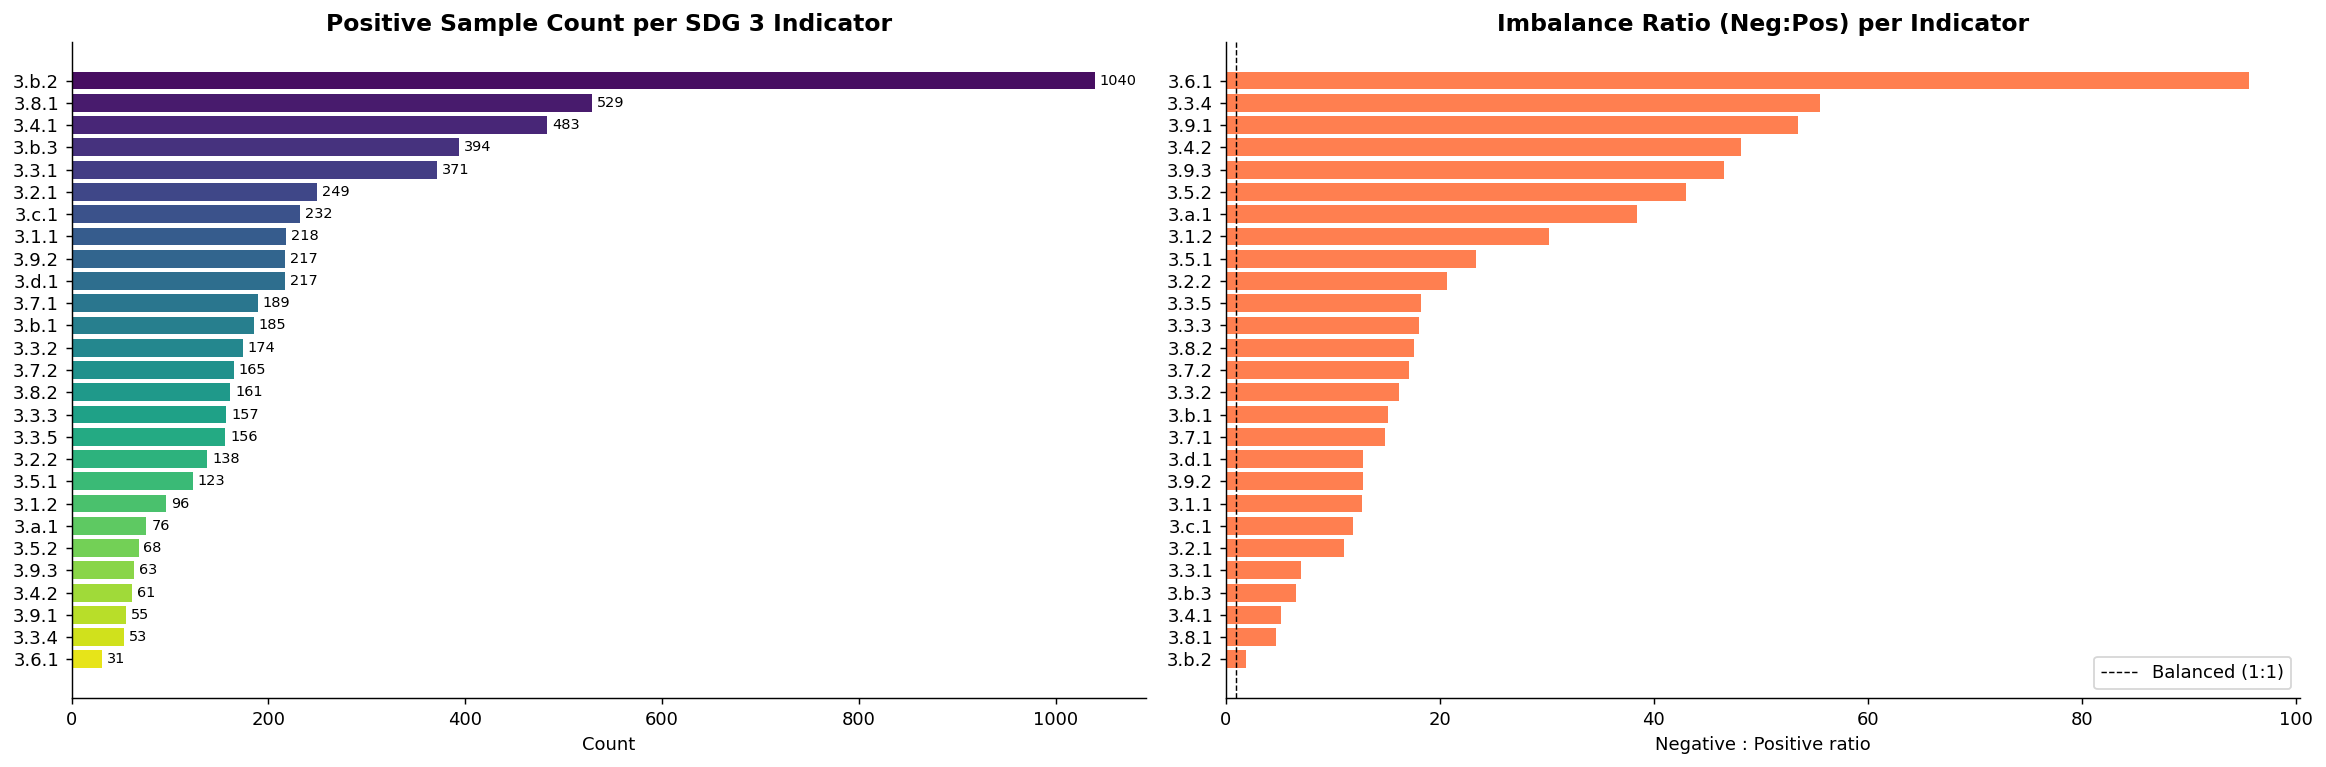


Most common : 3.b.2  →  1040 samples
Rarest      : 3.6.1  →  31 samples
Max imbalance ratio: 95.6:1  (3.6.1)


In [ ]:
label_counts = binary.sum().sort_values(ascending=False)
short_labels  = [SHORT_NAMES[i] for i in label_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar: counts
colors = sns.color_palette('viridis', len(ALL_INDICATORS))
axes[0].barh(short_labels[::-1], label_counts.values[::-1], color=colors[::-1])
axes[0].set_title('Positive Sample Count per SDG 3 Indicator', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(label_counts.values[::-1]):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=8)

# Bar: imbalance ratio
imbalance = ((len(df) - label_counts) / label_counts).sort_values(ascending=False)
axes[1].barh([SHORT_NAMES[i] for i in imbalance.index][::-1],
             imbalance.values[::-1], color='coral')
axes[1].axvline(1, color='black', linestyle='--', linewidth=0.8, label='Balanced (1:1)')
axes[1].set_title('Imbalance Ratio (Neg:Pos) per Indicator', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Negative : Positive ratio')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_label_distribution.png', bbox_inches='tight')
plt.show()

print(f'\nMost common : {label_counts.index[0].split(" - ")[0]}  →  {label_counts.iloc[0]} samples')
print(f'Rarest      : {label_counts.index[-1].split(" - ")[0]}  →  {label_counts.iloc[-1]} samples')
print(f'Max imbalance ratio: {imbalance.iloc[0]:.1f}:1  ({imbalance.index[0].split(" - ")[0]})')

**Labels per Sample and Document Types**

Most documents have only 1 or 2 labels, with a mean of 1.97. Tenders and Grants make up most of the dataset. Organization documents carry the most labels on average. This confirms the imbalance problem — for any document, roughly 25 of the 27 labels will always be zero.

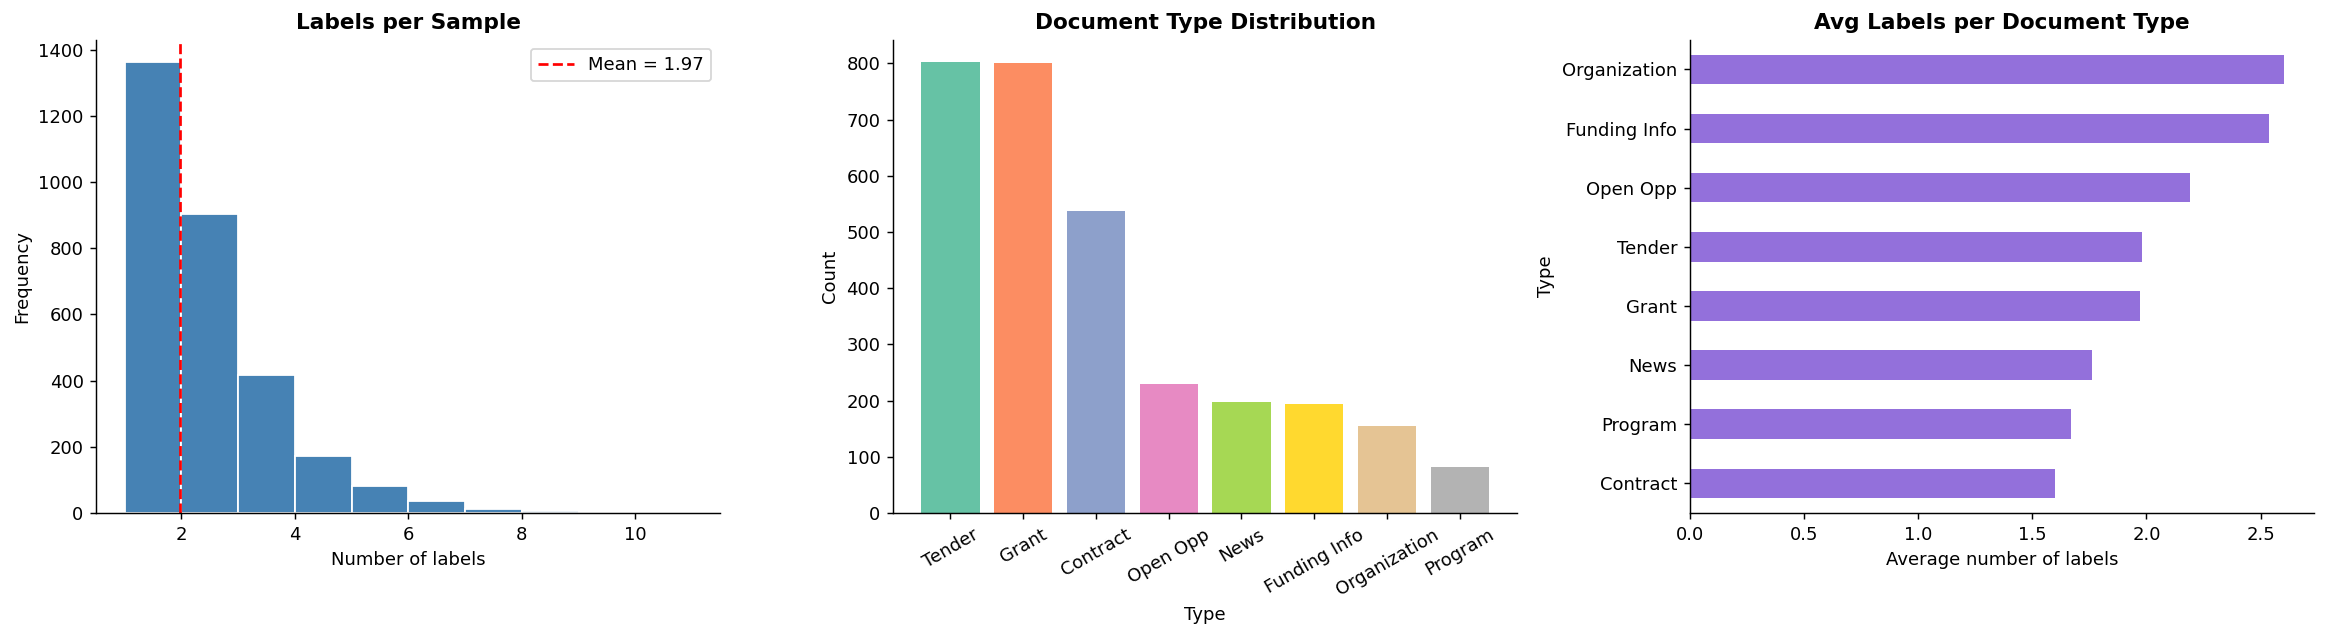


Samples with 1 label  : 1362  (45.5%)
Samples with 2 labels : 905  (30.2%)
Samples with 3+ labels: 728  (24.3%)


In [ ]:
labels_per_sample = binary.sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(labels_per_sample, bins=range(1, labels_per_sample.max()+2),
             color='steelblue', edgecolor='white')
axes[0].axvline(labels_per_sample.mean(), color='red', linestyle='--',
                label=f'Mean = {labels_per_sample.mean():.2f}')
axes[0].set_title('Labels per Sample', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of labels')
axes[0].set_ylabel('Frequency')
axes[0].legend()

type_counts = dataset[TYPE_COL].value_counts()
axes[1].bar(type_counts.index, type_counts.values,
            color=sns.color_palette('Set2', len(type_counts)))
axes[1].set_title('Document Type Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

avg_by_type = binary.groupby(df[TYPE_COL]).apply(lambda x: x.sum(axis=1).mean())
avg_by_type.sort_values().plot(kind='barh', ax=axes[2], color='mediumpurple')
axes[2].set_title('Avg Labels per Document Type', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Average number of labels')

plt.tight_layout()
plt.savefig('eda_type_distribution.png', bbox_inches='tight')
plt.show()

print(f'\nSamples with 1 label  : {(labels_per_sample==1).sum()}  ({(labels_per_sample==1).mean()*100:.1f}%)')
print(f'Samples with 2 labels : {(labels_per_sample==2).sum()}  ({(labels_per_sample==2).mean()*100:.1f}%)')
print(f'Samples with 3+ labels: {(labels_per_sample>=3).sum()}  ({(labels_per_sample>=3).mean()*100:.1f}%)')

**Co-occurrence Heatmap**

We look at which indicators tend to appear together. Clinically related indicators like Under-5 mortality and Neonatal mortality co-occur frequently, which makes sense. This shows the labels are not independent, something worth exploring in future modelling work.

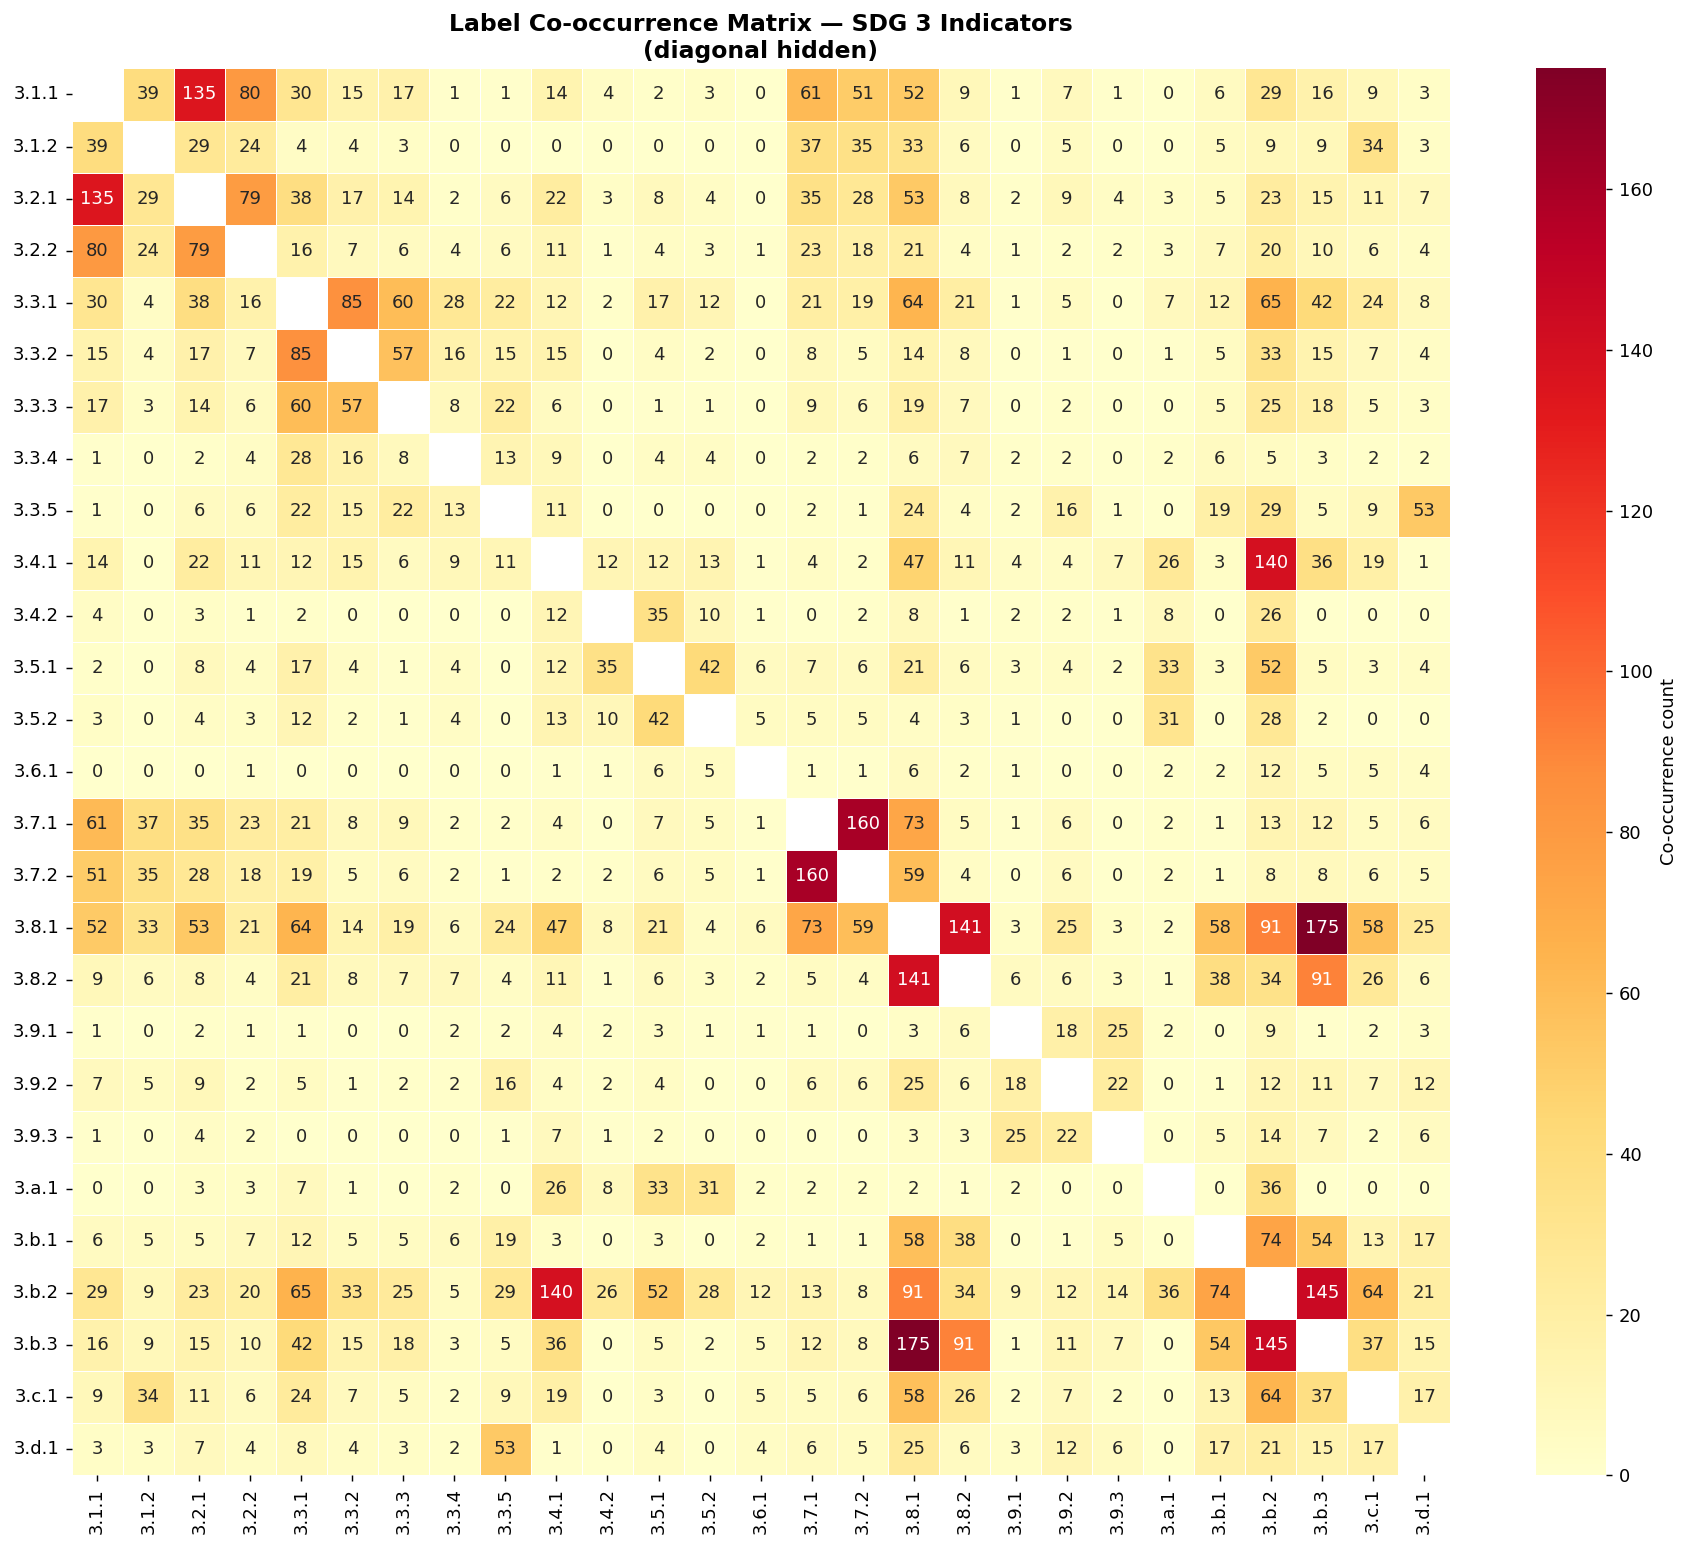

Saved: eda_cooccurrence.png


In [ ]:
co_occ = binary.T.dot(binary)
co_occ.index   = [SHORT_NAMES[i] for i in co_occ.index]
co_occ.columns = [SHORT_NAMES[i] for i in co_occ.columns]

mask = np.eye(len(co_occ), dtype=bool)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(co_occ, mask=mask, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Co-occurrence count'})
ax.set_title('Label Co-occurrence Matrix — SDG 3 Indicators\n(diagonal hidden)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_cooccurrence.png', bbox_inches='tight')
plt.show()
print('Saved: eda_cooccurrence.png')

**Word Clouds**

We visualise the most frequent words for the top six indicators. Each one has a clearly distinct vocabulary , HIV documents feature "antiretroviral" and "prevention", cardiovascular documents feature "diabetes" and "cancer". This confirms that TF-IDF will be informative for this task.

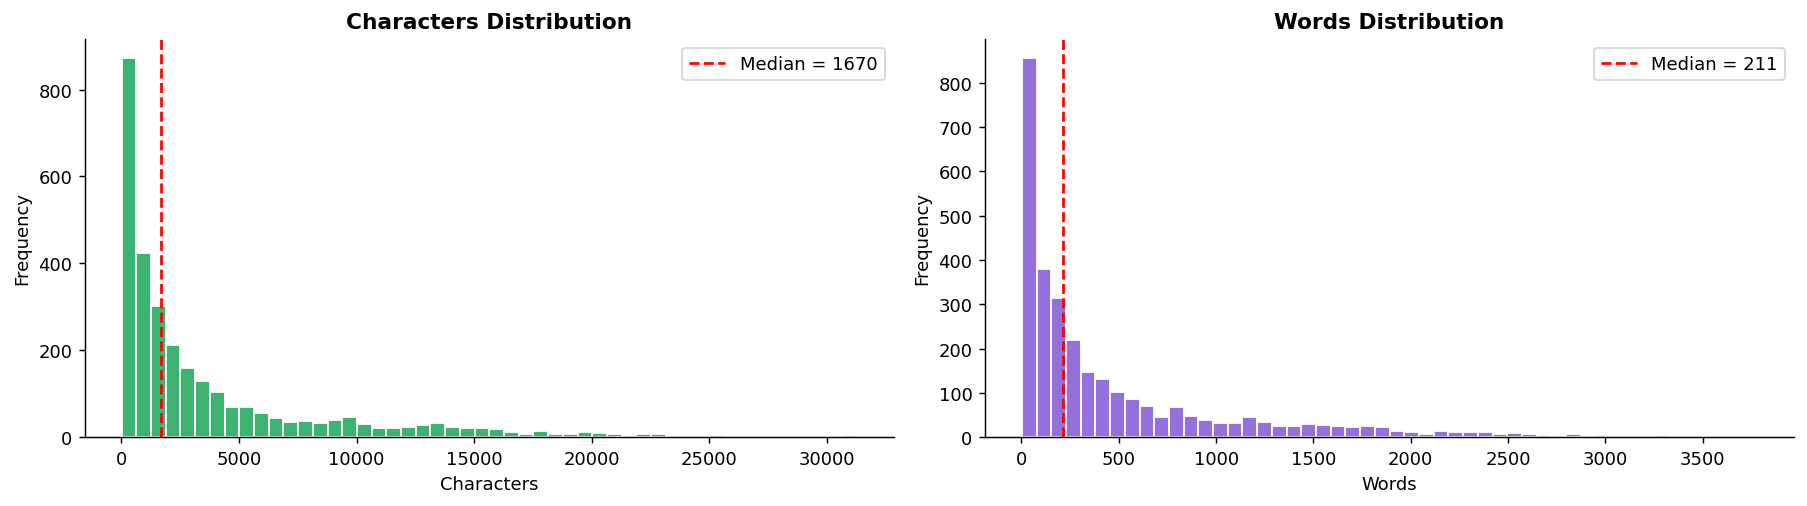

       text_len  word_count
count    2995.0      2995.0
mean     3820.6       477.7
std      5245.9       642.0
min        13.0         2.0
25%       131.0        18.0
50%      1670.0       211.0
75%      4794.0       618.5
max     31277.0      3781.0


In [ ]:
df['text_len']   = df[TEXT_COL].astype(str).str.len()
df['word_count'] = df[TEXT_COL].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, color, label in zip(
    axes,
    ['text_len', 'word_count'],
    ['mediumseagreen', 'mediumpurple'],
    ['Characters', 'Words']
):
    ax.hist(df[col], bins=50, color=color, edgecolor='white')
    ax.axvline(df[col].median(), color='red', linestyle='--',
               label=f'Median = {df[col].median():.0f}')
    ax.set_title(f'{label} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(label); ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_text_length.png', bbox_inches='tight')
plt.show()
print(df[['text_len','word_count']].describe().round(1))

**Text Length**

Documents vary enormously in length. The distribution is heavily right-skewed with some very long grant descriptions. This is why we truncate to 200 words for SBERT and why HTML stripping in preprocessing is essential.

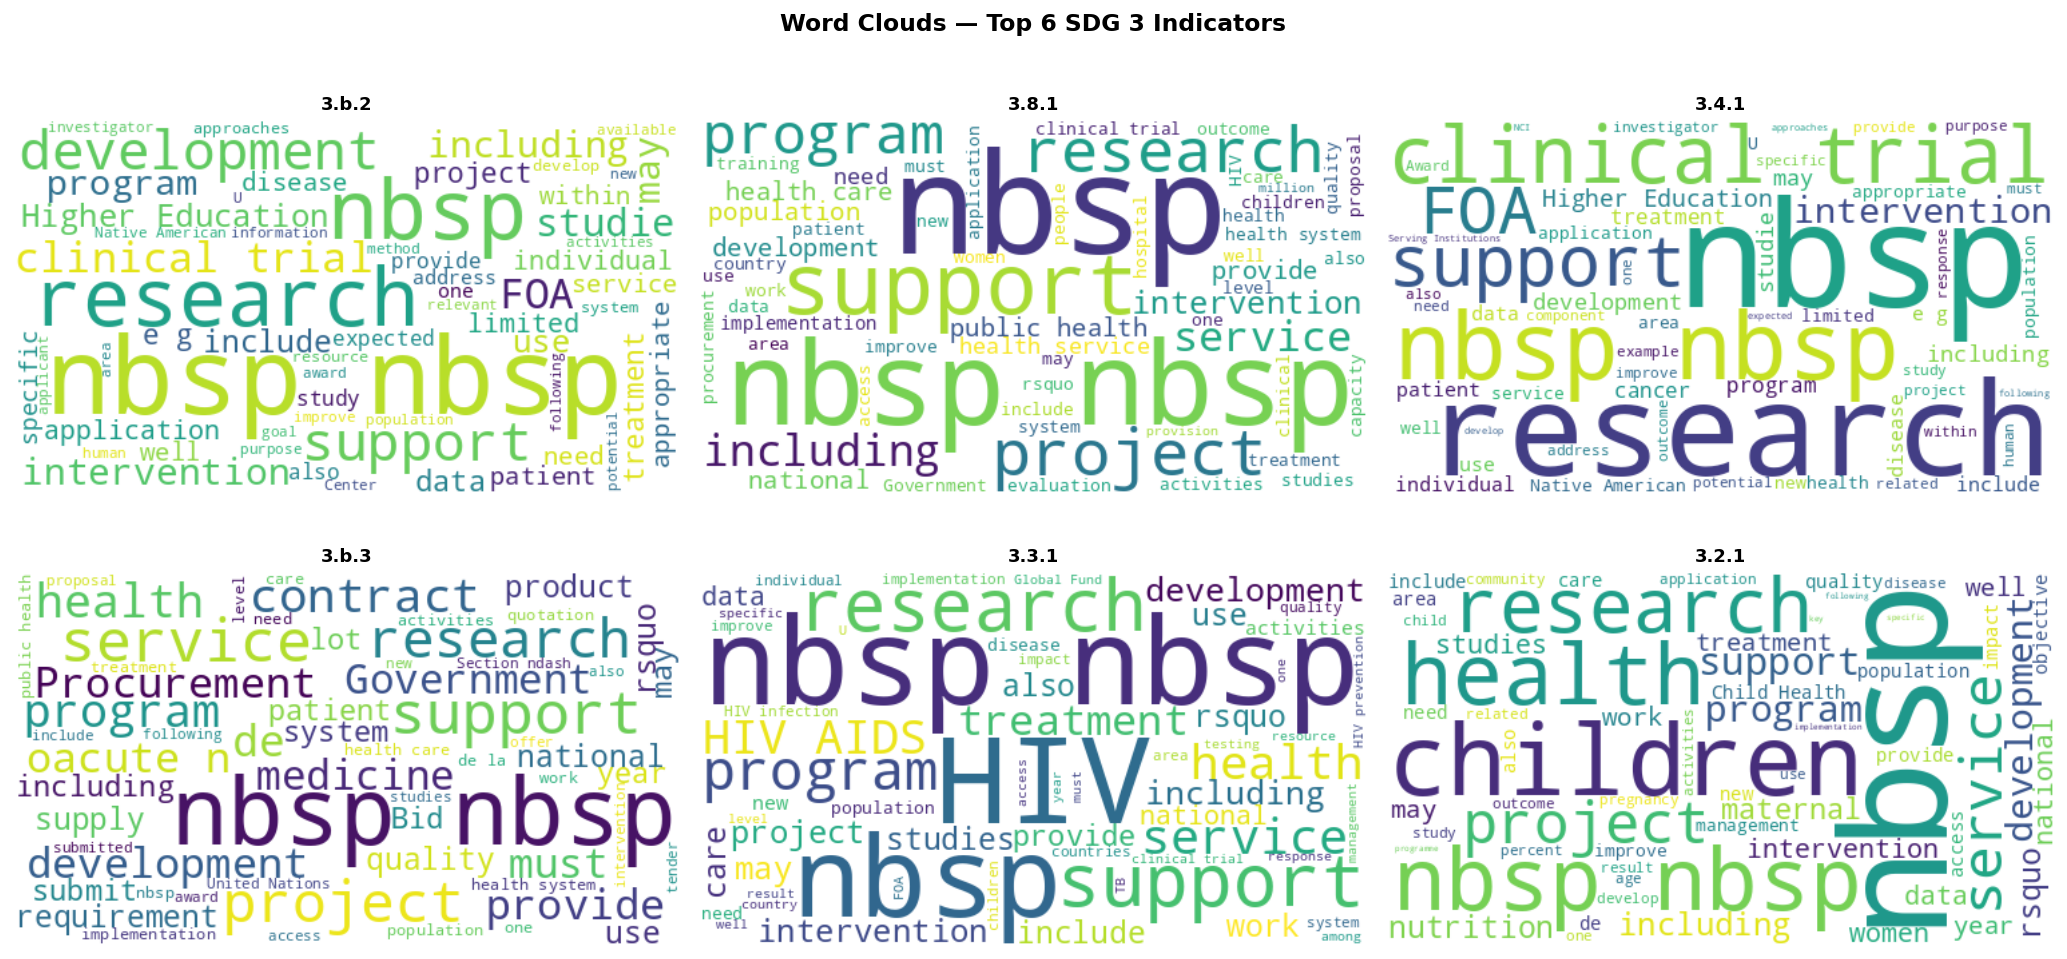

In [ ]:
stop_words  = set(stopwords.words('english'))
top_6_labels = binary.sum().sort_values(ascending=False).index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, indicator in enumerate(top_6_labels):
    texts = df[df[indicator] == 1][TEXT_COL].astype(str).str.cat(sep=' ')
    # strip HTML
    texts = re.sub(r'<[^>]+>', ' ', texts)
    wc = WordCloud(width=500, height=280, background_color='white',
                   stopwords=stop_words, colormap='viridis', max_words=60).generate(texts)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(SHORT_NAMES[indicator], fontsize=10, fontweight='bold')

plt.suptitle('Word Clouds — Top 6 SDG 3 Indicators', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_wordclouds.png', bbox_inches='tight')
plt.show()

**Preprocessing**

We build a cleaning function that strips HTML, removes URLs, lowercases, removes stopwords, and lemmatizes each word. We deliberately keep SDG-critical words like "hiv", "malaria", and "maternal" that NLTK would normally strip, since these are the most important signal for classification.

In [ ]:
lemmatizer = WordNetLemmatizer()

SDG_KEEP = {
    'health','mortality','maternal','neonatal','disease','hiv','aids',
    'malaria','tuberculosis','mental','substance','vaccine','water',
    'sanitation','hygiene','nutrition','sexual','reproductive','death',
    'birth','child','infant','tobacco','alcohol','injury','universal'
}
STOP_WORDS = set(stopwords.words('english')) - SDG_KEEP

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)           # strip HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  # remove URLs
    text = re.sub(r'\b\d{4}\b', ' year ', text)    # normalise years
    text = re.sub(r'[^a-z\s]', ' ', text)          # keep alpha only
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def lemmatize_text(text: str) -> str:
    text   = clean_text(text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

print('Applying preprocessing...')
df['text_clean'] = df[TEXT_COL].apply(clean_text)
df['text_lemma'] = df[TEXT_COL].apply(lemmatize_text)

print('\nRaw sample:')
print(df[TEXT_COL].iloc[0][:200])
print('\nAfter preprocessing:')
print(df['text_lemma'].iloc[0][:200])

Applying preprocessing...

Raw sample:
Centers of Biomedical Research Excellence (COBRE) Phase III - Transitional Centers     <p><strong>Funding Opportunity Description</strong></p>    <p><a name="_Toc258873267"></a>The Institutional Devel

After preprocessing:
center biomedical research excellence cobre phase iii transitional center funding opportunity description institutional development award idea program endeavor stimulate research institution state tra


**Feature Engineering**

We build four feature sets , TF-IDF word n-grams (50,000 features), TF-IDF character n-grams (30,000 features), SBERT dense embeddings (384 features), and a combined SBERT + TF-IDF matrix (50,384 features).The train/val split is 85/15 giving 2,545 training and 450 validation documents.


In [ ]:
from sklearn.model_selection import train_test_split

X_all = df['text_lemma'].values
y_all = binary.values

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.15, random_state=SEED
)
print(f'Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}')


tfidf_word = TfidfVectorizer(ngram_range=(1,2), max_features=50_000,
                              sublinear_tf=True, min_df=2, max_df=0.95)
X_train_tfidf = tfidf_word.fit_transform(X_train)
X_val_tfidf   = tfidf_word.transform(X_val)


tfidf_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5),
                              max_features=30_000, sublinear_tf=True, min_df=3)
X_train_char = tfidf_char.fit_transform(X_train)
X_val_char   = tfidf_char.transform(X_val)


X_train_combined_tfidf = hstack([X_train_tfidf, X_train_char])
X_val_combined_tfidf   = hstack([X_val_tfidf,   X_val_char])

print(f'TF-IDF word shape     : {X_train_tfidf.shape}')
print(f'TF-IDF char shape     : {X_train_char.shape}')
print(f'Combined TF-IDF shape : {X_train_combined_tfidf.shape}')

Train: 2545  |  Val: 450
TF-IDF word shape     : (2545, 50000)
TF-IDF char shape     : (2545, 30000)
Combined TF-IDF shape : (2545, 80000)


In [ ]:
from sentence_transformers import SentenceTransformer

def truncate(text, max_words=200):
    return ' '.join(str(text).split()[:max_words])

X_train_trunc = [truncate(t) for t in X_train]
X_val_trunc   = [truncate(t) for t in X_val]

sbert = SentenceTransformer('all-MiniLM-L6-v2')

print('Encoding train set...')
X_train_sbert = sbert.encode(X_train_trunc, batch_size=64,
                               show_progress_bar=True, normalize_embeddings=True)
print('Encoding val set...')
X_val_sbert   = sbert.encode(X_val_trunc, batch_size=64,
                               show_progress_bar=True, normalize_embeddings=True)

X_train_final = hstack([csr_matrix(X_train_sbert), X_train_tfidf])
X_val_final   = hstack([csr_matrix(X_val_sbert),   X_val_tfidf])

print(f'\nSBERT shape         : {X_train_sbert.shape}')
print(f'SBERT+TF-IDF shape  : {X_train_final.shape}')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Encoding train set...


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Encoding val set...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]


SBERT shape         : (2545, 384)
SBERT+TF-IDF shape  : (2545, 50384)


In [ ]:
# SAVE PROCESSED DATA FOR TEAM HANDOFF
import os
from scipy.sparse import save_npz

SAVE_DIR = '/content/processed_data'
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Raw text (needed for BERT / any model that takes raw strings) ---
np.save(f'{SAVE_DIR}/X_train_text.npy', X_train)
np.save(f'{SAVE_DIR}/X_val_text.npy',   X_val)

# --- Labels ---
np.save(f'{SAVE_DIR}/y_train.npy', y_train)
np.save(f'{SAVE_DIR}/y_val.npy',   y_val)

# --- TF-IDF word features (sparse) ---
save_npz(f'{SAVE_DIR}/X_train_tfidf.npz',          X_train_tfidf)
save_npz(f'{SAVE_DIR}/X_val_tfidf.npz',            X_val_tfidf)

# --- TF-IDF char features (sparse) ---
save_npz(f'{SAVE_DIR}/X_train_char.npz',           X_train_char)
save_npz(f'{SAVE_DIR}/X_val_char.npz',             X_val_char)

# --- Combined TF-IDF (word + char) ---
save_npz(f'{SAVE_DIR}/X_train_combined_tfidf.npz', X_train_combined_tfidf)
save_npz(f'{SAVE_DIR}/X_val_combined_tfidf.npz',   X_val_combined_tfidf)

# --- SBERT dense embeddings ---
np.save(f'{SAVE_DIR}/X_train_sbert.npy', X_train_sbert)
np.save(f'{SAVE_DIR}/X_val_sbert.npy',   X_val_sbert)

# --- Combined SBERT + TF-IDF (sparse) ---
save_npz(f'{SAVE_DIR}/X_train_final.npz', X_train_final)
save_npz(f'{SAVE_DIR}/X_val_final.npz',   X_val_final)

# --- Save indicator names so other notebooks know the label order ---
np.save(f'{SAVE_DIR}/indicator_names.npy', np.array(ALL_INDICATORS))

print(" All processed data saved to:", SAVE_DIR)
print("\nFiles saved:")
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f'{SAVE_DIR}/{f}') / 1024
    print(f"  {f:<40} {size:>8.1f} KB")

 All processed data saved to: /content/processed_data

Files saved:
  X_train_char.npz                          31979.5 KB
  X_train_combined_tfidf.npz                37581.2 KB
  X_train_final.npz                          9454.0 KB
  X_train_sbert.npy                          3817.6 KB
  X_train_text.npy                           6257.6 KB
  X_train_tfidf.npz                          4742.2 KB
  X_val_char.npz                             5462.7 KB
  X_val_combined_tfidf.npz                   6220.1 KB
  X_val_final.npz                            1577.9 KB
  X_val_sbert.npy                             675.1 KB
  X_val_text.npy                             1096.1 KB
  X_val_tfidf.npz                             766.3 KB
  indicator_names.npy                          34.9 KB
  y_train.npy                                 537.0 KB
  y_val.npy                                    95.0 KB


In [ ]:
from google.colab import drive
import shutil, os

# Mount Google Drive
drive.mount('/content/drive')

# Create shared folder
DRIVE_DIR = '/content/drive/MyDrive/SDG_Assignment/processed_data'
os.makedirs(DRIVE_DIR, exist_ok=True)

LOCAL_DIR = '/content/processed_data'
for fname in os.listdir(LOCAL_DIR):
    shutil.copy2(f'{LOCAL_DIR}/{fname}', f'{DRIVE_DIR}/{fname}')
    print(f' {fname}')


print(f'\n Done files are in Google Drive at:')
print(f'   {DRIVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 X_val_text.npy
 y_train.npy
 X_train_char.npz
 X_val_combined_tfidf.npz
 X_val_final.npz
 X_train_text.npy
 y_val.npy
 X_val_tfidf.npz
 X_train_combined_tfidf.npz
 X_val_char.npz
 X_train_sbert.npy
 X_train_final.npz
 indicator_names.npy
 X_train_tfidf.npz
 X_val_sbert.npy

 Done files are in Google Drive at:
   /content/drive/MyDrive/SDG_Assignment/processed_data
